<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Hands on

## Import modules

In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import pickle

In [2]:
tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 16,
    "font.size": 16,
    "figure.titlesize": 16,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
}

plt.rcParams.update(tex_fonts)

%matplotlib inline
# %matplotlib notebook
%config InlineBackend.figure_format='svg'
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Unsupervised learning for regression
0. Preprocess data

1. Create/build model

2. Fit/Evaluate model

3. Hands on

## 0. (Pre)process data

In [4]:
# Loading dataset
iris_df = datasets.load_iris()

In [5]:
# Available methods on dataset
dir(iris_df)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [6]:
# Features
iris_df.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
# Targets
iris_df.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
# Target Names
iris_df.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

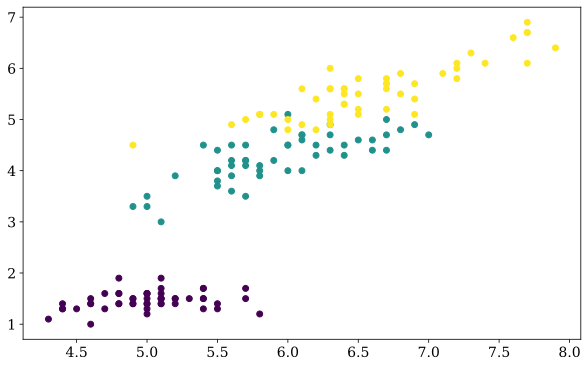

In [9]:
# Dataset Slicing
x_axis = iris_df.data[:, 0]  # Sepal Length
y_axis = iris_df.data[:, 2]  # Sepal Width

# Plotting
plt.scatter(x_axis, y_axis, c=iris_df.target)
plt.show()

---
# You're on your own ;)
### Let's find our clusters!

In [10]:
from sklearn.cluster import KMeans

# aux function for elbow method implementation
def elbow_method(X_train, n):
    wcss = []
    # calculate Within Cluster Sum of Squares (WCSS) for KMeans with 1-n clusters
    for i in range(1, n):
        kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
        kmeans.fit(X_train)
        wcss.append(kmeans.inertia_)
    
    fig = plt.figure()
    
    plt.plot(range(1, n), wcss)
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()

## 0. (Pre)process data

In [11]:
iris_data = iris_df.data

### Find number of clusters using elbow method

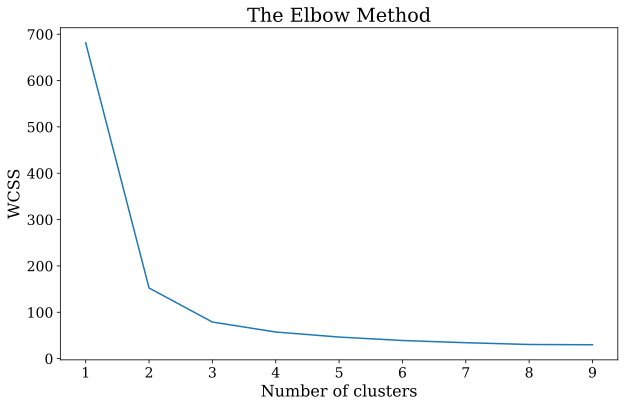

In [12]:
elbow_method(iris_data, 10)

## Declaring Model
hint: model_kmeans = ...

In [13]:
model_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=1233)

In [14]:
# random_state = 100?
# model_kmeans = ??

model_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=100)

## Model fitting

### Make predictions on the entire data

In [15]:
# all_predictions = model_kmeans.??
all_predictions = model_kmeans.fit_predict(iris_data)

### Printing predictions

In [16]:
# Printing Predictions
print(all_predictions)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


#### How many datapoints are set in each cluster?

In [17]:
for p in np.unique(all_predictions):
    print(f'{len(all_predictions[all_predictions==p])} of examples are set in cluster {p}.')

61 of examples are set in cluster 0.
50 of examples are set in cluster 1.
39 of examples are set in cluster 2.


In [18]:
iris_results = {'setosa': [], 'versicolor': [], 'virginica': []}

for y_pred, y_true in zip(all_predictions, iris_df.target):
    print(f'{y_pred}: {iris_df.target_names[y_true]}')
    iris_results[iris_df.target_names[y_true]].append(y_pred)

1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
1: setosa
2: versicolor
0: versicolor
2: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
2: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versicolor
0: versico

In [19]:
setosa = np.array(iris_results.get('setosa'))
versicolor = np.array(iris_results.get('versicolor'))
virginica = np.array(iris_results.get('virginica'))

In [20]:
def clustering_stats(d, name=''):
    for spec in np.unique(d):
        spec_perc_in_cluster = len(d[d==spec]) / len(d)
        print(f'{spec_perc_in_cluster * 100:.2f}% of Iris {name} has label {spec}.')

In [21]:
clustering_stats(setosa, 'setosa')

100.00% of Iris setosa has label 1.


In [22]:
clustering_stats(versicolor, 'versicolor')

94.00% of Iris versicolor has label 0.
6.00% of Iris versicolor has label 2.


In [23]:
clustering_stats(virginica, 'virginica')

28.00% of Iris virginica has label 0.
72.00% of Iris virginica has label 2.


In [24]:
# If you're satisfied with the model, save it to disk
filename = '../models/kmeans_handson.pkl'
pickle.dump(model_kmeans, open(filename, 'wb'))
 
# load the model from disk
# model_kmeans = pickle.load(open(filename, 'rb'))
# result = model_kmeans.predict(X_test)

# Resume

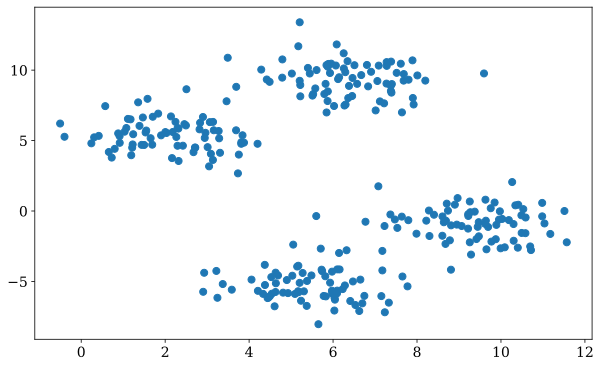

In [25]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=1.2, random_state=13)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [26]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

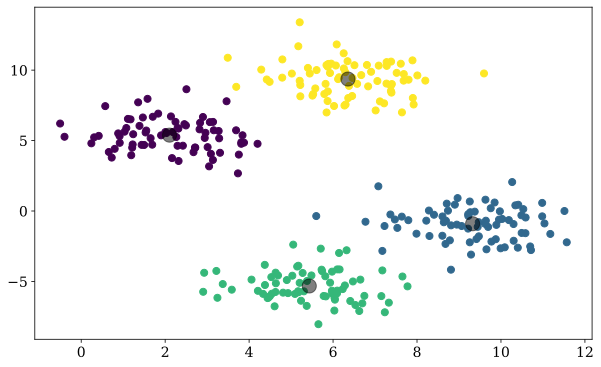

In [27]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

### Complicated stuff

In [28]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

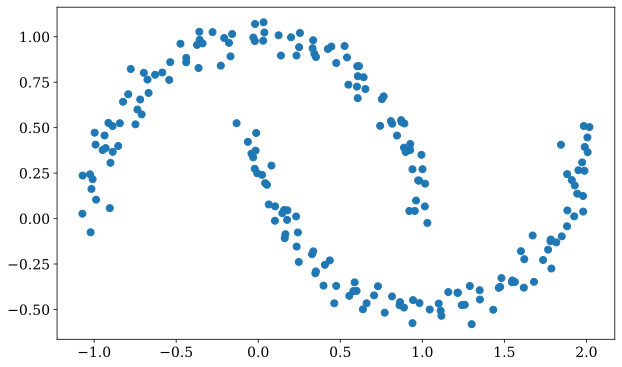

In [29]:
plt.scatter(X[:, 0], X[:, 1], s=50);

In [30]:
kmeans = KMeans(2, random_state=0)
labels = kmeans.fit_predict(X)

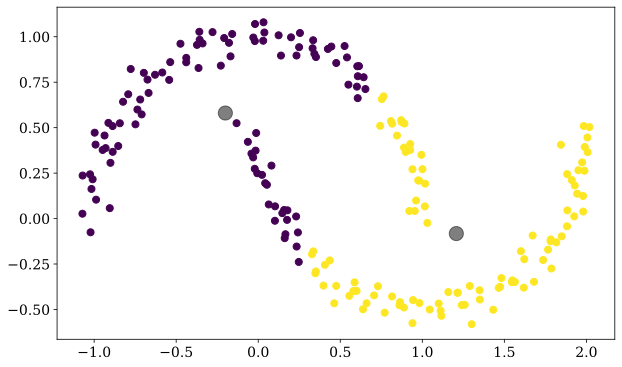

In [31]:
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

### Some support vector machine-like magic

In [32]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')

In [33]:
labels = model.fit_predict(X)

In [34]:
model.get_params

<bound method BaseEstimator.get_params of SpectralClustering(affinity='nearest_neighbors', n_clusters=2)>

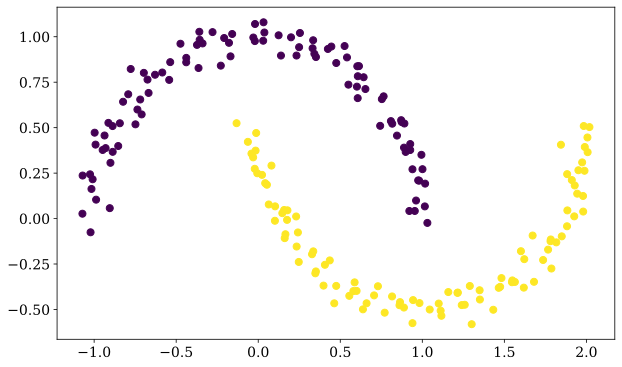

In [35]:
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');



_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 3c_Unsupervised_Iris_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Iris dataset: https://archive.ics.uci.edu/dataset/53/iris_
- _FISHER, R.A. (1936), THE USE OF MULTIPLE MEASUREMENTS IN TAXONOMIC PROBLEMS. Annals of Eugenics, 7: 179-188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x_
- _Scikit-learn Clustering: https: //scikit-learn.org/1.5/modules/clustering.html_
- _Scikit-learn KMeans clustering: https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans_
- _Scikit-learn Spectral clustering: https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.SpectralClustering.html_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

